In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn nltk xgboost imbalanced-learn wordcloud joblib scipy

  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Us


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE

import nltk
import re
import joblib

In [ ]:
# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gowri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gowri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gowri\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
# Load the dataset
df = pd.read_csv("../data/fake_job_postings.csv")

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [5]:
#Explore the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [6]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

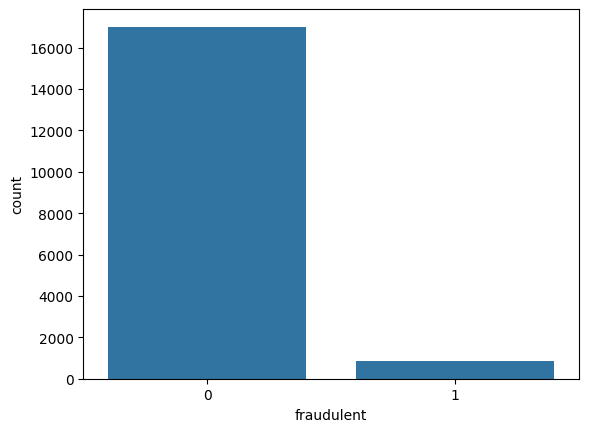

In [7]:
sns.countplot(x='fraudulent', data=df)
plt.show()

In [ ]:
#NLP Preprocessing
#combine text columns into a single column for NLP processing
text_columns = ['title','company_profile','description','requirements','benefits']

df[text_columns] = df[text_columns].fillna("")

df['text_combined'] = df[text_columns].agg(' '.join, axis=1)

In [ ]:
#Text cleaning function

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

def clean_text(text):

    text=text.lower()
    text=re.sub(r'<.*?>','',text)
    text=re.sub(r'[^a-zA-Z ]','',text)

    words=text.split()

    words=[lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text']=df['text_combined'].apply(clean_text)

In [10]:
# text vectorization using TF-IDF
vectorizer=TfidfVectorizer(max_features=5000,ngram_range=(1,2))

X_text=vectorizer.fit_transform(df['clean_text'])

y=df['fraudulent']

In [11]:
# Train-test split
X_train,X_test,y_train,y_test=train_test_split(
    X_text,y,test_size=0.2,stratify=y,random_state=42
)

In [12]:
# SMOTE oversampling
smote=SMOTE(random_state=42)

X_train_sm,y_train_sm=smote.fit_resample(X_train,y_train)

In [ ]:
# Model training 
models={
"LogisticRegression":LogisticRegression(),
"NaiveBayes":MultinomialNB(),
"SVC":SVC(probability=True),
"RandomForest":RandomForestClassifier(),
"AdaBoost":AdaBoostClassifier(),
"XGBoost":XGBClassifier(eval_metric="logloss")
}

In [14]:
# Model evaluation
results=[]

for name,model in models.items():

    model.fit(X_train_sm,y_train_sm)

    pred=model.predict(X_test)

    acc=accuracy_score(y_test,pred)
    prec=precision_score(y_test,pred)
    rec=recall_score(y_test,pred)
    f1=f1_score(y_test,pred)

    results.append([name,acc,prec,rec,f1])

In [15]:
# Model comparison
results_df=pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1"])

results_df.sort_values("F1",ascending=False)

,Model,Accuracy,Precision,Recall,F1
2,SVC,0.984340,1.000000,0.676301,0.806897
3,RandomForest,0.982662,0.991150,0.647399,0.783217
5,XGBoost,0.981264,0.889706,0.699422,0.783172
0,LogisticRegression,0.973993,0.686916,0.849711,0.759690
1,NaiveBayes,0.913870,0.349666,0.907514,0.504823
4,AdaBoost,0.900168,0.292793,0.751445,0.421394


In [16]:
# Feature importance for tree-based models

model=models["RandomForest"]

importance=model.feature_importances_

features=vectorizer.get_feature_names_out()

feat_df=pd.DataFrame({"feature":features,"importance":importance})

feat_df.sort_values("importance",ascending=False).head(20)

,feature,importance
1321,earn,0.011182
1050,data entry,0.009131
1309,duty,0.008715
3157,per,0.008328
1482,entry,0.007954
3263,position,0.007790
1951,growing,0.007647
4369,team,0.007315
3122,passionate,0.006689
4041,skill,0.006482


(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

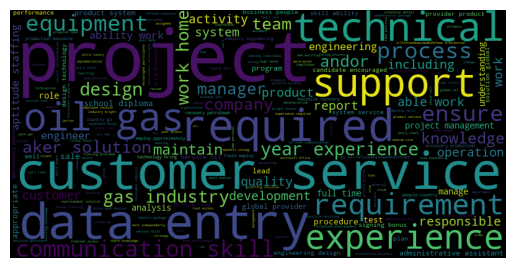

In [17]:
# word cloud for important features

from wordcloud import WordCloud

fraud_text=" ".join(df[df.fraudulent==1]['clean_text'])

wc=WordCloud(width=800,height=400).generate(fraud_text)

plt.imshow(wc)
plt.axis("off")

In [18]:
# Save the best model
best_model=models["XGBoost"]

joblib.dump(best_model,"../models/fraud_model.pkl")

joblib.dump(vectorizer,"../models/tfidf.pkl")

['../models/tfidf.pkl']

In [19]:
# Prediction pipeline
def predict_job(text):

    cleaned=clean_text(text)

    vec=vectorizer.transform([cleaned])

    pred=best_model.predict(vec)[0]

    return "Fraudulent" if pred==1 else "Legitimate"